# Coronal-Loop Reconstruction — Keras 3 — PyTorch Backend

This research workflow reconstructs a loop's z profile from its projected
x/y coordinates and three archived scalar descriptors. It corrects the
overlapping split in the legacy notebook: loops 0–2999 train, 3000–3749
validate, and 3750–4999 form the untouched final test set. All normalization is
fit on training loops only.

Set `HELIO_FAST_RUN=1` to use fewer loops and every tenth point. In Colab,
choose **Runtime → Run all**; the bootstrap verifies each archived array.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'keras': 'keras', 'torch': 'torch'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Keras-to-PyTorch crosswalk

This optional implementation uses the same Torch runtime as the canonical
native PyTorch path. Keras `compile()` selects the optimizer and loss,
`fit()` owns the explicit batch and epoch loop, and callbacks provide
high-level training control. Data, splits, budgets, evidence, and scientific
conclusions remain aligned with the canonical PyTorch workflow.

## Imports and deterministic configuration

In [3]:
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
FAST_RUN = os.getenv("HELIO_FAST_RUN", "0") == "1"
random.seed(SEED)
np.random.seed(SEED)

## Resolve the immutable arrays

In [4]:
import hashlib
import os
from pathlib import Path
from urllib.parse import quote
from urllib.request import urlopen

DATASET_ID = 'coronal-loops'
DATASET_FILES = {'X2D.npy': ('data/coronal-loops/X2D.npy', '48fdc54c387642ed1dba563b3a27e5aa666327689d0b8db67355aa3015c0d658'), 'Y2D.npy': ('data/coronal-loops/Y2D.npy', 'f5500bd93a542facd44bb0710abc2880bb0ea8ff7e769f64eb8332898c1bd35b'), 'LNGTH_L2D.npy': ('data/coronal-loops/LNGTH_L2D.npy', '38511b43978701e420cfd262fb98dfa2c816dbe8bb7f2ecd2759124073beb988'), 'DST2D_FP.npy': ('data/coronal-loops/DST2D_FP.npy', 'ff6e05c3679aa876beb390a2fe4531992e2752360b66fe0bcfbb8057bd9c6a0e'), 'angle_top.npy': ('data/coronal-loops/angle_top.npy', '4fb89537bb58b44f75ff222dbb53ea8596b1f2900657bbbf3d0eff2fc45796b2'), 'Z3D.npy': ('data/coronal-loops/Z3D.npy', '9c04fd96c1c158607259cfbc9ac8e758cfaaf50f627622ee3e9761323b6b8bac')}


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def resolve_dataset():
    resolved = {}
    override = os.getenv("HELIO_DATA_DIR")
    cache_root = Path(
        os.getenv("HELIO_DATA_CACHE", Path.home() / ".cache" / "helio-data-methods")
    ) / "datasets" / DATASET_ID
    for filename, (relative_path, checksum) in DATASET_FILES.items():
        candidates = []
        if override:
            root = Path(override).expanduser()
            candidates.extend([root / DATASET_ID / filename, root / filename])
        for root in [Path.cwd(), *Path.cwd().parents]:
            candidates.append(root / relative_path)
        target = cache_root / filename
        candidates.append(target)
        match = next(
            (
                candidate
                for candidate in candidates
                if candidate.is_file() and file_sha256(candidate) == checksum
            ),
            None,
        )
        if match is None:
            target.parent.mkdir(parents=True, exist_ok=True)
            ref = os.getenv("HELIO_DATA_REF", "main")
            url = (
                "https://raw.githubusercontent.com/SavvasRaptis/helio-data-methods/"
                f"{quote(ref, safe='')}/{quote(relative_path, safe='/')}"
            )
            try:
                with urlopen(url, timeout=120) as response, target.open("wb") as output:
                    while chunk := response.read(1024 * 1024):
                        output.write(chunk)
            except Exception as exc:
                target.unlink(missing_ok=True)
                raise RuntimeError(
                    f"Could not retrieve {DATASET_ID}/{filename}. Check network "
                    "access or set HELIO_DATA_DIR to the archived data directory."
                ) from exc
            if file_sha256(target) != checksum:
                target.unlink(missing_ok=True)
                raise ValueError(
                    f"Checksum mismatch for {DATASET_ID}/{filename}; "
                    "the invalid download was removed."
                )
            match = target
        resolved[filename] = match
    return resolved


dataset_files = resolve_dataset()
print("verified dataset:", DATASET_ID)
for name in dataset_files:
    print(f"  {name} (checksum verified)")

verified dataset: coronal-loops
  X2D.npy: data/coronal-loops/X2D.npy
  Y2D.npy: data/coronal-loops/Y2D.npy
  LNGTH_L2D.npy: data/coronal-loops/LNGTH_L2D.npy
  DST2D_FP.npy: data/coronal-loops/DST2D_FP.npy
  angle_top.npy: data/coronal-loops/angle_top.npy
  Z3D.npy: data/coronal-loops/Z3D.npy


## Assemble features and apply the corrected split

In [5]:
x_coordinates = np.load(dataset_files["X2D.npy"], mmap_mode="r")
y_coordinates = np.load(dataset_files["Y2D.npy"], mmap_mode="r")
z_coordinates = np.load(dataset_files["Z3D.npy"], mmap_mode="r")
length = np.load(dataset_files["LNGTH_L2D.npy"]).astype(np.float32)
footpoint_distance = np.load(dataset_files["DST2D_FP.npy"]).astype(np.float32)
top_angle = np.load(dataset_files["angle_top.npy"]).astype(np.float32)

point_slice = slice(None, None, 10) if FAST_RUN else slice(None)
train_indices = np.arange(0, 300 if FAST_RUN else 3000)
validation_indices = np.arange(3000, 3150 if FAST_RUN else 3750)
test_indices = np.arange(3750, 3900 if FAST_RUN else 5000)


def assemble(indices):
    x = np.asarray(x_coordinates[point_slice, indices], dtype=np.float32).T
    y = np.asarray(y_coordinates[point_slice, indices], dtype=np.float32).T
    z = np.asarray(z_coordinates[point_slice, indices], dtype=np.float32).T
    points = x.shape[1]
    scalars = np.stack(
        [length[indices], footpoint_distance[indices], top_angle[indices]], axis=1
    )
    scalar_channels = np.repeat(scalars[:, None, :], points, axis=1)
    features = np.concatenate([x[..., None], y[..., None], scalar_channels], axis=2)
    return features, z


x_train_raw, y_train_raw = assemble(train_indices)
x_validation_raw, y_validation_raw = assemble(validation_indices)
x_test_raw, y_test_raw = assemble(test_indices)

feature_mean = x_train_raw.mean(axis=(0, 1), keepdims=True)
feature_std = x_train_raw.std(axis=(0, 1), keepdims=True)
feature_std[feature_std < 1e-7] = 1
target_mean = y_train_raw.mean(axis=0, keepdims=True)
target_std = y_train_raw.std(axis=0, keepdims=True)
target_std[target_std < 1e-7] = 1

x_train = ((x_train_raw - feature_mean) / feature_std).astype(np.float32)
x_validation = ((x_validation_raw - feature_mean) / feature_std).astype(np.float32)
x_test = ((x_test_raw - feature_mean) / feature_std).astype(np.float32)
y_train = ((y_train_raw - target_mean) / target_std).astype(np.float32)
y_validation = ((y_validation_raw - target_mean) / target_std).astype(np.float32)
training_mean_prediction = np.repeat(target_mean, len(y_test_raw), axis=0)

assert train_indices.max() < validation_indices.min() < test_indices.min()
print(
    f"train={len(train_indices)}, validation={len(validation_indices)}, "
    f"test={len(test_indices)}, points per loop={y_train.shape[1]}"
)

train=3000, validation=750, test=1250, points per loop=1500


## Train the Keras convolutional regressor

In [6]:
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch
from keras import layers

keras.utils.set_random_seed(SEED)
torch.use_deterministic_algorithms(True)
assert keras.backend.backend() == "torch"
model = keras.Sequential(
    [
        keras.Input(shape=x_train.shape[1:]),
        layers.Conv1D(32, 25, padding="same", activation="relu"),
        layers.MaxPooling1D(4),
        layers.Conv1D(64, 15, padding="same", activation="relu"),
        layers.MaxPooling1D(4),
        layers.Conv1D(64, 7, padding="same", activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(256, activation="relu"),
        layers.Dense(y_train.shape[1]),
    ]
)
model.compile(optimizer=keras.optimizers.Adam(), loss="mse")
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_validation, y_validation),
    epochs=1 if FAST_RUN else 10,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True
        )
    ],
    verbose=2,
)
predictions_scaled = model.predict(x_test, verbose=0)
predictions = predictions_scaled * target_std + target_mean
losses = history.history

Epoch 1/10


94/94 - 1s - 11ms/step - loss: 0.2151 - val_loss: 17.2635


Epoch 2/10


94/94 - 1s - 8ms/step - loss: 0.0582 - val_loss: 16.2637


Epoch 3/10


...

94/94 - 1s - 8ms/step - loss: 0.0400 - val_loss: 9.4868


Epoch 7/10


94/94 - 1s - 8ms/step - loss: 0.0333 - val_loss: 10.2177


Epoch 8/10


94/94 - 1s - 8ms/step - loss: 0.0303 - val_loss: 10.3896


## Inspect learning curves

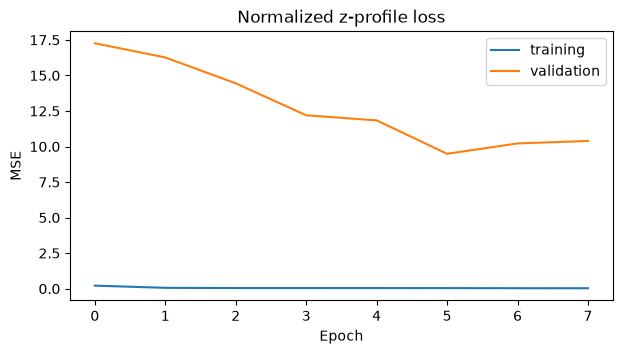

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(losses["loss"], label="training")
ax.plot(losses["val_loss"], label="validation")
ax.set(title="Normalized z-profile loss", xlabel="Epoch", ylabel="MSE")
ax.legend()
plt.show()

## Compare with the training-mean profile

model: {
  "point_mae": 13.339418411254883,
  "point_rmse": 17.805435653708656,
  "r2": -17.02708625793457,
  "loop_mae_mean": 13.339418411254883,
  "loop_mae_median": 14.348398208618164,
  "loop_rmse_mean": 14.37874984741211
}
training-mean z-profile baseline: {
  "point_mae": 1.526468276977539,
  "point_rmse": 1.9913593440856479,
  "r2": 0.7745139598846436,
  "loop_mae_mean": 1.5264685153961182,
  "loop_mae_median": 1.3986599445343018,
  "loop_rmse_mean": 1.778918981552124
}


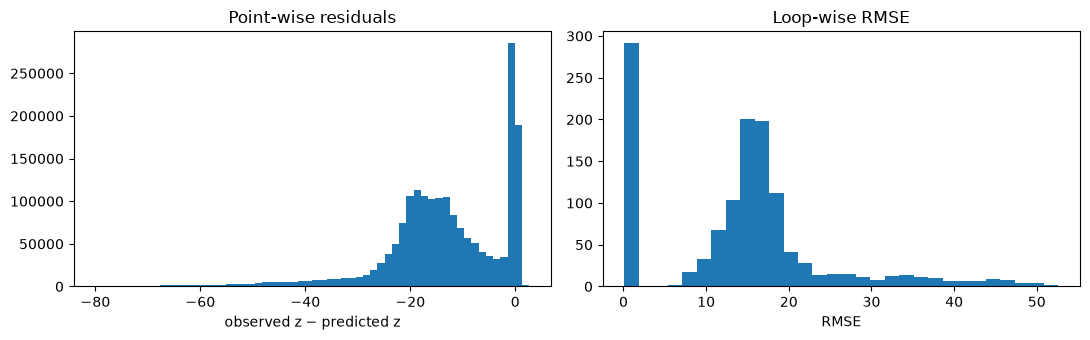

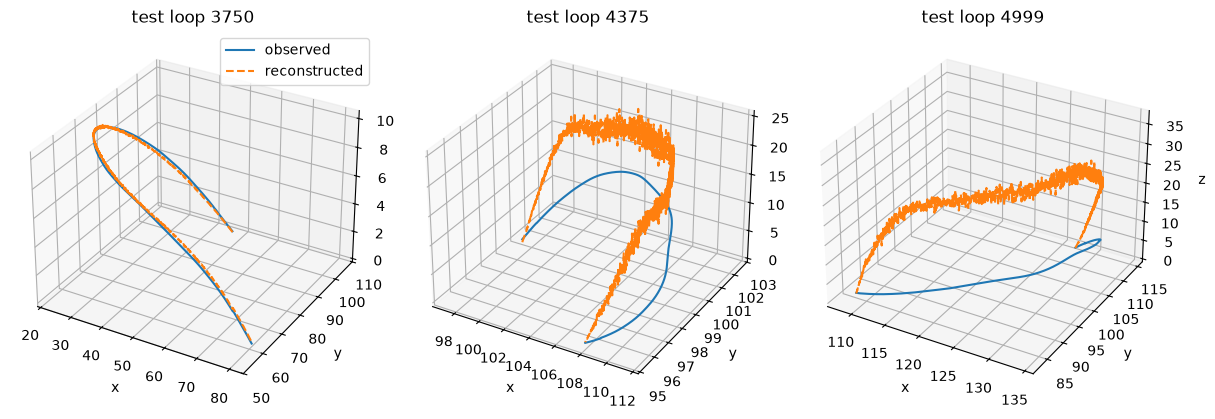

HELIO_RESULT {"baseline_point_rmse": 1.9913593440856479, "model_loop_rmse": 14.37874984741211, "model_point_rmse": 17.805435653708656, "prediction_shape": [1250, 1500], "split": {"test": [3750, 4999], "train": [0, 2999], "validation": [3000, 3749]}}


In [8]:
def regression_evidence(y_true, y_prediction):
    point_mae = float(mean_absolute_error(y_true.ravel(), y_prediction.ravel()))
    point_rmse = float(mean_squared_error(y_true.ravel(), y_prediction.ravel()) ** 0.5)
    loop_mae = np.mean(np.abs(y_true - y_prediction), axis=1)
    loop_rmse = np.sqrt(np.mean((y_true - y_prediction) ** 2, axis=1))
    return {
        "point_mae": point_mae,
        "point_rmse": point_rmse,
        "r2": float(r2_score(y_true.ravel(), y_prediction.ravel())),
        "loop_mae_mean": float(loop_mae.mean()),
        "loop_mae_median": float(np.median(loop_mae)),
        "loop_rmse_mean": float(loop_rmse.mean()),
    }


model_evidence = regression_evidence(y_test_raw, predictions)
baseline_evidence = regression_evidence(y_test_raw, training_mean_prediction)
print("model:", json.dumps(model_evidence, indent=2))
print("training-mean z-profile baseline:", json.dumps(baseline_evidence, indent=2))

residuals = y_test_raw - predictions
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(residuals.ravel(), bins=60)
axes[0].set(title="Point-wise residuals", xlabel="observed z − predicted z")
loop_rmse = np.sqrt(np.mean(residuals**2, axis=1))
axes[1].hist(loop_rmse, bins=30)
axes[1].set(title="Loop-wise RMSE", xlabel="RMSE")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(12, 4))
for panel, index in enumerate([0, len(y_test_raw) // 2, len(y_test_raw) - 1], start=1):
    axis = fig.add_subplot(1, 3, panel, projection="3d")
    axis.plot(
        x_test_raw[index, :, 0],
        x_test_raw[index, :, 1],
        y_test_raw[index],
        label="observed",
    )
    axis.plot(
        x_test_raw[index, :, 0],
        x_test_raw[index, :, 1],
        predictions[index],
        label="reconstructed",
        linestyle="--",
    )
    axis.set_title(f"test loop {test_indices[index]}")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_zlabel("z")
axes = fig.axes
axes[0].legend()
plt.tight_layout()
plt.show()

print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "model_point_rmse": model_evidence["point_rmse"],
            "baseline_point_rmse": baseline_evidence["point_rmse"],
            "model_loop_rmse": model_evidence["loop_rmse_mean"],
            "prediction_shape": list(predictions.shape),
            "split": {"train": [0, 2999], "validation": [3000, 3749], "test": [3750, 4999]},
        },
        sort_keys=True,
    )
)
assert predictions.shape == y_test_raw.shape
assert np.isfinite(predictions).all()

## Scientific boundary

The reconstruction is evaluated only against the supplied arrays. Their
archive does not contain enough provenance to make claims about broader solar
populations, measurement uncertainty, or out-of-distribution performance.